####======================================================
### **Homework Assignment 6**
### Saurav Luthra, 55027009
### **ECE 648 - Machine Learning**

#### ====================================================
#### INTRODUCTION + OVERVIEW
#### ======================================================

This assignment focuses on analyzing vertebral column data from *Vertebral_column_3C.dat* to examine relationships between biomechanical features and the orthopaedic patients' classes (disk hernia, normal, spondilolysthesis). The dataset contains 310 data points (rows) and has 7 features (columns), including the label. For this assignment, the DH and SL labels were grouped into 1 label (ABNORMAL = 0) and NO was kept the same (NORMAL = 1). The aim is to create a random forest classifier, adaboost classifier, and an XGboost classifier. The models' prediction accuracies were calculated and plotted with varying n_trees values. Also, these models' n_trees and max_depths were optimized over specified spaces using k-fold cross-validation with 10 folds. To achieve this the sklearn, numpy, pandas, seaborn, xgboost, and matplotlib packages were used.

The following steps were performed:

1. Values for 6 independent variables/features (unnamed) and the class, *label*, were loaded into a DataFrame. The data was split into a training set and testing set, with the DH and SL labels being grouped together. This leaves only 2 (binary) labels. The X feature matrix was standardized using scaler.

2. Random Forest (RF)

    a) Created an RF with n_trees = 1000 and max_depth = 6. Found the prediction accuracy on the test data.

    b) Created a set of RFs with 14 n_trees values, and max_depth = 6. Calculated and plotted the prediction accuracy of each RF on the test data versus n_trees.

    c) Used grid search and 10-fold CV to find the best RF over a 4x4 parameter space of max_depth and n_trees. Calculated the prediction accuracy of the best model on the test data.

3. AdaBoost (ADA)

    a) Created an ADA with base model = decision tree, n_trees = 500, learning_rate =  0.1, and max_depth = 5. Found the prediction accuracy on the test data.

    b) Created a set of ADAs with 14 n_trees values, and max_depth = 5. Calculated and plotted the prediction accuracy of each ADA on the test data versus n_trees.

    c) Used grid search and 10-fold CV to find the best ADA over a 4 value parameter space of n_trees. max_depth = 5. Calculated the prediction accuracy of the best model on the test data.

4. XGBoost (XGB)

    a) Created a set of XGBs with 14 n_trees values, learning_rate = 0.01, and max_depth = 6. Calculated and plotted the prediction accuracy of each XGB on the test data versus n_trees

    b) Used grid search and 10-fold CV to find the best XGB over a 4x4 parameter space of max_depth and n_trees. learning_rate = 0.01. Calculated the prediction accuracy of the best model on the test data.


#### ====================================================
#### IMPORT PACKAGES
#### ======================================================

In [189]:
from distutils.version import LooseVersion

import matplotlib
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

import seaborn as sns

import sklearn
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

from xgboost import XGBClassifier, XGBRegressor

#### ====================================================
#### LOAD DATA INTO DATAFRAME
#### ======================================================

In [190]:
# create dataframe (df) from the input file
df = pd.read_csv('Vertebral_column_3C.dat', sep = '\s+', header = None)

# check df columns for missing values
df.isnull().sum().to_frame().transpose()

,0,1,2,3,4,5,6
0,0,0,0,0,0,0,0


In [191]:
# make X matrix and rename columns
X = df.iloc[:, :6].rename(columns = {0: 'f0', 1: 'f1', 2: 'f2', 3: 'f3', 4: 'f4', 5: 'f5'})

In [192]:
X

,f0,f1,f2,f3,f4,f5
0,63.03,22.55,39.61,40.48,98.67,-0.25
1,39.06,10.06,25.02,29.00,114.41,4.56
2,68.83,22.22,50.09,46.61,105.99,-3.53
3,69.30,24.65,44.31,44.64,101.87,11.21
4,49.71,9.65,28.32,40.06,108.17,7.92
...,...,...,...,...,...,...
305,47.90,13.62,36.00,34.29,117.45,-4.25
306,53.94,20.72,29.22,33.22,114.37,-0.42
307,61.45,22.69,46.17,38.75,125.67,-2.71
308,45.25,8.69,41.58,36.56,118.55,0.21


In [193]:
# make y vector and map the labels to integers
# both DH and SL are abnormal (0) and NO is normal (1)

# 0 - disk hernia       - DH
# 0 - spondilolysthesis - SL
# 1 - normal            - NO

y = df.iloc[:, 6:].rename(columns={6: 'label'})

mapping = {'DH': 0, 'SL': 0, 'NO': 1}
y['label'] = y['label'].map(mapping)

y

,label
0,0
1,0
2,0
3,0
4,0
...,...
305,1
306,1
307,1
308,1


In [194]:
# get count of labels in y
y['label'].value_counts()

,count
label,
0,210
1,100


In [195]:
# split data into a training set (70%) and a testing set (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 305, stratify = y)

In [196]:
# get counts of labels in y_train and y_test
print(y_train['label'].value_counts())
print(y_test['label'].value_counts())

label
0    147
1     70
Name: count, dtype: int64
label
0    63
1    30
Name: count, dtype: int64


In [197]:
# standardize features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [198]:
# transform the y vectors to be 1D arrays
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

In [199]:
# class label names
class_labels = ["ABNORMAL", "NORMAL"]

#### ====================================================
#### RANDOM FOREST
#### ======================================================

In [200]:
# number of folds for random forest cross-validation
cv_k = 10

# number of trees for the random forests
n_trees11 = 1000
n_trees12 = [10,50,100,200,300,400,600,800,1000,1200,1400,1600,1800,2000]
n_trees13 = [100,400,1000,1500]

# max tree depth
max_depth11 = 6
max_depth12 = 6
max_depth13 = [5,6,7,8]

In [201]:
# train a random forest
rf1 = RandomForestClassifier(n_estimators=n_trees11, max_depth=max_depth11, random_state=305)
rf1.fit(X_train, y_train)

# predict on test data
y_pred11 = rf1.predict(X_test)

# calculate the prediction accuracy
print(f"Prediction Accuracy: {accuracy_score(y_test, y_pred11):.3f}")

Prediction Accuracy: 0.806




NUMBER OF TREES | PREDICTION ACCURACY
      10        |        0.785        
      50        |        0.828        
      100       |        0.806        
      200       |        0.796        
      300       |        0.796        
      400       |        0.796        
      600       |        0.806        
      800       |        0.806        
     1000       |        0.806        
     1200       |        0.806        
     1400       |        0.806        
     1600       |        0.806        
     1800       |        0.806        
     2000       |        0.806        


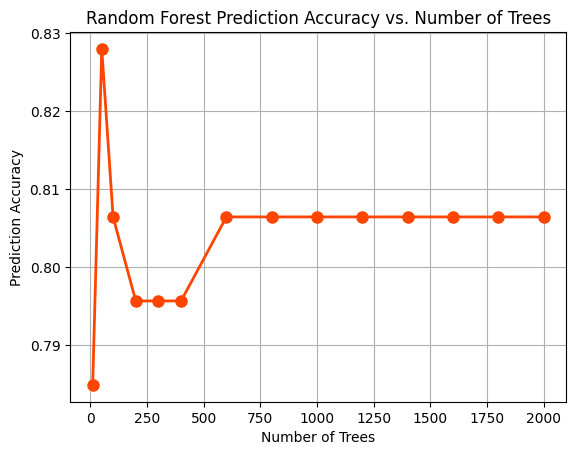

In [202]:
# build multiple random forest models and plot their prediction accuracy (stores in points list) vs. size (n_trees)
points = []

# header for table of accuracies
print("\n\nNUMBER OF TREES | PREDICTION ACCURACY")
print("======================================")

for n_trees in n_trees12:

    # create a new rf with n_trees
    rf2 = RandomForestClassifier(n_estimators=n_trees, max_depth=max_depth12, bootstrap=True, random_state=305)
    rf2.fit(X_train, y_train)

    # get predicted values from rf
    y_pred12 = rf2.predict(X_test)

    # accuracy score of rf on test data
    prediction_accuracy = accuracy_score(y_test, y_pred12)

    # print n_trees and accuracy to table
    print(f"{n_trees:^15} | {prediction_accuracy:^20.3f}")

    # append accuracy to points list
    points.append(prediction_accuracy)


# plot points and join them with lines
plt.plot(n_trees12, points, marker='o', linestyle='-', color='orangered', markersize=8, linewidth=2)

# add labels and title
plt.xlabel("Number of Trees")
plt.ylabel("Prediction Accuracy")
plt.title("Random Forest Prediction Accuracy vs. Number of Trees")

# show plot
plt.grid(True)
plt.show()



In [203]:
# build a rf classifier. choose the optimal max_depth and n_trees using cv
rf3 = RandomForestClassifier(bootstrap=True, random_state = 305)

# use cross validation to choose the optimal max_depth and n_trees combination
CV1 = sklearn.model_selection.GridSearchCV(rf3, param_grid = {'max_depth': max_depth13, 'n_estimators': n_trees13}, cv = cv_k, n_jobs=-1)
CV1.fit(X_train, y_train)

rf3 = CV1.best_estimator_

y_pred13 = rf3.predict(X_test)

In [204]:
# print best hyperparameters
print("Best Parameters:", CV1.best_params_)

# get the prediction accuracy of the model
print(f"Prediction Accuracy: {accuracy_score(y_test, y_pred13):.3f}")

# evaluate best model on test data
print(f"Test Accuracy: {rf3.score(X_test, y_test):3f}")

Best Parameters: {'max_depth': 6, 'n_estimators': 1000}
Prediction Accuracy: 0.806
Test Accuracy: 0.806452


#### ====================================================
#### ADABOOST
#### ======================================================



In [205]:
# number of folds for cross-validation
cv_k = 10

# number of trees for the random forests
n_trees21 = 500
n_trees22 = [10,50,100,200,300,400,600,800,1000,1200,1400,1600,1800,2000]
n_trees23 = [100,400,1000,1500]

# max tree depths
max_depth21 = 5
max_depth22 = 5
max_depth23 = 5

# learning rates
learning_rate21 = 0.1
learning_rate22 = 0.1
learning_rate23 = 0.1

In [206]:
# train an adaBoost classifier with a decision tree being the base model, the number of trees being 500, and calculate the prediction accuracy on the test data
ada1 = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=max_depth21), n_estimators=n_trees21, learning_rate=learning_rate21, random_state=305)
ada1.fit(X_train, y_train)

# predict on test data
y_pred21 = ada1.predict(X_test)

# calculate the prediction accuracy
print(f"Prediction Accuracy: {accuracy_score(y_test, y_pred21):.3f}")

Prediction Accuracy: 0.806




NUMBER OF TREES | PREDICTION ACCURACY
      10        |        0.763        
      50        |        0.796        
      100       |        0.763        
      200       |        0.763        
      300       |        0.817        
      400       |        0.796        
      600       |        0.806        
      800       |        0.806        
     1000       |        0.817        
     1200       |        0.817        
     1400       |        0.806        
     1600       |        0.817        
     1800       |        0.806        
     2000       |        0.806        


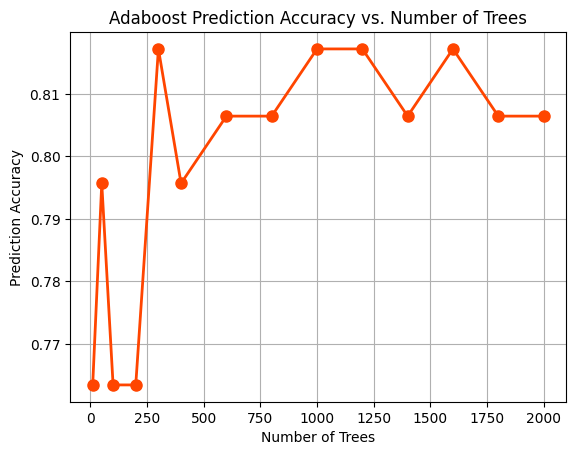

In [207]:
# build multiple adaboost models and plot their prediction accuracy (stores in points list) vs. size (n_trees)
points = []

# header for table of accuracies
print("\n\nNUMBER OF TREES | PREDICTION ACCURACY")
print("======================================")

for n_trees in n_trees22:

  # train an adaBoost classifier with the n_trees trees, and calculate the prediction accuracy on the test data
  ada2 = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=max_depth22), n_estimators=n_trees, learning_rate=learning_rate22, random_state=305)
  ada2.fit(X_train, y_train)

  # predict on test data
  y_pred22 = ada2.predict(X_test)

  # accuracy score of rf on test data
  prediction_accuracy = accuracy_score(y_test, y_pred22)

  # print n_trees and accuracy to table
  print(f"{n_trees:^15} | {prediction_accuracy:^20.3f}")

  # append accuracy to points list
  points.append(prediction_accuracy)


# plot points and join them with lines
plt.plot(n_trees22, points, marker='o', linestyle='-', color='orangered', markersize=8, linewidth=2)

# add labels and title
plt.xlabel("Number of Trees")
plt.ylabel("Prediction Accuracy")
plt.title("Adaboost Prediction Accuracy vs. Number of Trees")

# show plot
plt.grid(True)
plt.show()



In [208]:
# build an adaboost classifier. choose the optimal n_trees using cv
ada3 = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=max_depth23), learning_rate=learning_rate23, random_state=305)

# use cross validation to choose the optimal n_trees
CV2 = sklearn.model_selection.GridSearchCV(ada3, param_grid = {'n_estimators': n_trees23}, cv = cv_k, n_jobs=-1)
CV2.fit(X_train, y_train)

ada3 = CV2.best_estimator_

# predict on test data
y_pred23 = ada3.predict(X_test)

In [209]:
# print best hyperparameters
print("Best Parameters:", CV2.best_params_)

# output prediction accuracy of the model
print(f"Prediction Accuracy: {accuracy_score(y_test, y_pred23):.3f}")

# evaluate best model on test data
print(f"Test Accuracy: {ada3.score(X_test, y_test):3f}")

Best Parameters: {'n_estimators': 100}
Prediction Accuracy: 0.763
Test Accuracy: 0.763441


#### ====================================================
#### GRADIENT BOOSTING
#### ======================================================

In [210]:
# number of folds for cross-validation
cv_k = 10

# number of trees for the random forests
n_trees31 = [10,50,100,200,300,400,600,800,1000,1200,1400,1600,1800,2000]
n_trees32 = [100,400,1000,1500]

# max tree depths
max_depth31 = 6
max_depth32 = [5,6,7,8]

# learning rates
learning_rate31 = 0.01
learning_rate32 = 0.01



NUMBER OF TREES | PREDICTION ACCURACY
      10        |        0.677        
      50        |        0.731        
      100       |        0.785        
      200       |        0.763        
      300       |        0.753        
      400       |        0.753        
      600       |        0.742        
      800       |        0.753        
     1000       |        0.753        
     1200       |        0.753        
     1400       |        0.753        
     1600       |        0.774        
     1800       |        0.796        
     2000       |        0.796        


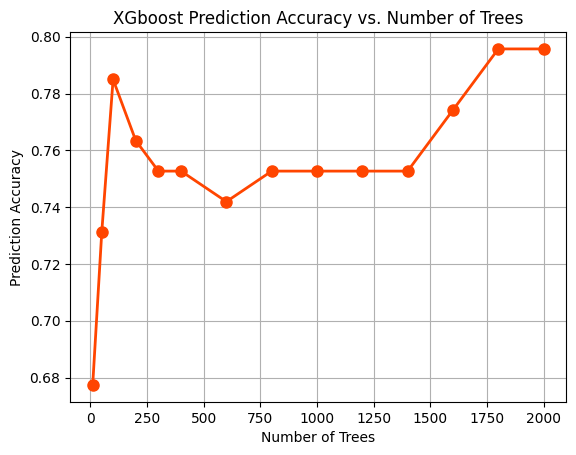

In [211]:
# build multiple xgboost models and plot their prediction accuracy (stores in points list) vs. size (n_trees)
points = []

# header for table of accuracies
print("\n\nNUMBER OF TREES | PREDICTION ACCURACY")
print("======================================")

for n_trees in n_trees31:

  # train an xgBoost classifier with the n_trees trees, and calculate the prediction accuracy on the test data
  xgb1 = XGBClassifier(n_estimators=n_trees, max_depth=max_depth31, learning_rate=learning_rate31, random_state=305)
  xgb1.fit(X_train, y_train)

  # predict on test data
  y_pred31 = xgb1.predict(X_test)

  # accuracy score of xgb on test data
  prediction_accuracy = accuracy_score(y_test, y_pred31)

  # print n_trees and accuracy to table
  print(f"{n_trees:^15} | {prediction_accuracy:^20.3f}")

  # append accuracy to points list
  points.append(prediction_accuracy)


# plot points and join them with lines
plt.plot(n_trees31, points, marker='o', linestyle='-', color='orangered', markersize=8, linewidth=2)

# add labels and title
plt.xlabel("Number of Trees")
plt.ylabel("Prediction Accuracy")
plt.title("XGboost Prediction Accuracy vs. Number of Trees")

# show plot
plt.grid(True)
plt.show()



In [212]:
# build an xgboost classifier. choose the optimal max_depth and n_trees using cv
xgb2 = XGBClassifier(learning_rate=learning_rate32, random_state=305)

# use cross validation to choose the optimal n_trees
CV3 = sklearn.model_selection.GridSearchCV(xgb2, param_grid = {'n_estimators': n_trees32, 'max_depth': max_depth32}, cv=cv_k, n_jobs=-1)
CV3.fit(X_train, y_train)

xgb2 = CV3.best_estimator_

# predict on test data
y_pred32 = xgb2.predict(X_test)

In [213]:
# print best hyperparameters
print("Best Parameters:", CV3.best_params_)

# print the models prediction accuracy
print(f"Prediction Accuracy: {accuracy_score(y_test, y_pred32):.3f}")

# evaluate best model on test data
print(f"Test Accuracy: {xgb2.score(X_test, y_test):3f}")

Best Parameters: {'max_depth': 7, 'n_estimators': 1000}
Prediction Accuracy: 0.753
Test Accuracy: 0.752688
